# Model Spikey observed by Plato(Sim) with JAXNS

In this notebook we use the Bayesian inference package `JAXNS`, using nested sampling, to model the Plato simulation of Spikey.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Built-in
import os
import sys
import json
import copy

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
# NumPyro
import numpyro
import numpyro.distributions as dist
# Select number of CPUs
numpyro.enable_x64()
numpyro.set_host_device_count(6)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

INFO:2026-03-07 17:47:58,847:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [4]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
c = 'royalblue'

---
## 1. Model Q
---

---
## 2.1. Model DM
---

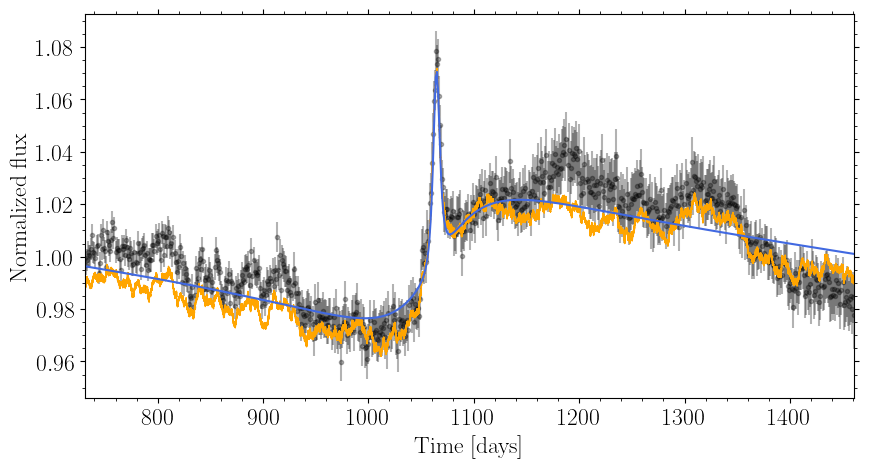

In [5]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_feather(ddir / 'lc_spikey_fiducial_1h.ftr')

# Bin to 1-hour light curve 
df = ut.bin_lc(df, bin_size=1)
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.t0    = 0.712
params.sigma = 0 
params.seed  = params.seed
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Load variable template
sdir = path / '../workdir/smbhb/simulations/lcs/'
dv = pd.read_csv(sdir / 'varsource' / 'varsource_spikey_fiducial.txt', 
                 sep=' ', names=['time', 'dmag'])
dv.time /= 86400
dv['flux'] = ut.mag2flux(dv.dmag)

# Cut light curve to 2-year duration
tdur = 2 * ut.year2sec() / ut.day2sec()
df = df[df.time < 2*tdur]
time = df.time.to_numpy()

# Plot light curve
fig, ax = pt.plot_lc(df, dv, cm='orange', lw=1, alpha=0.3)
ax.plot(dm.time, dm.flux, '-', c=c);

In [10]:
# We use wide uninformative uniform priors
odir = rdir / 'spikey_plato_bin1d2yr_DM_jaxns'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'vz'   : params.vz,
}

In [ ]:
%%time
result = bs.run_jaxns(df, params, priors, bs.smbhb_mean_builder, ofile=odir/'result.npy')
result = ut.load_result(odir / 'result.npy')

INFO:jaxns:Number of Markov-chains set to: 2000


Running over 6 devices.


In [9]:
# Show results
dm = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3)
fig = pt.plot_corner(result, best_params='mle', true_params=True, color=c);

KeyError: 'likelihood'

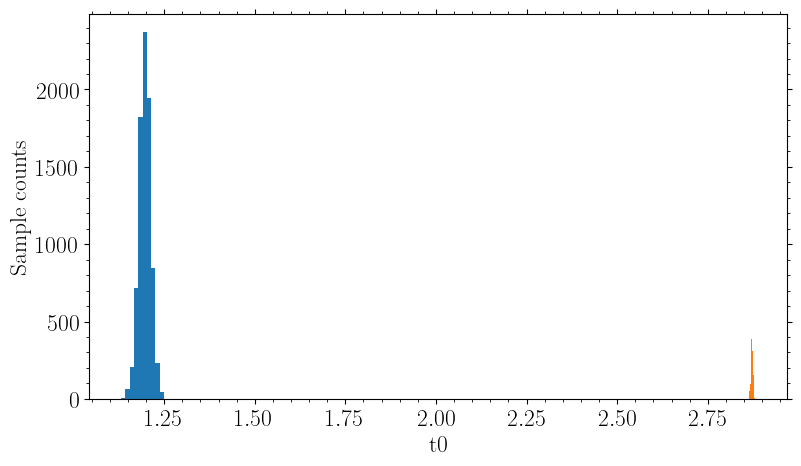

In [9]:
# Resolve bimodality in t0
clusters = bs.get_posterior_clusters(df, result, param_cluster='t0', n_components=2)

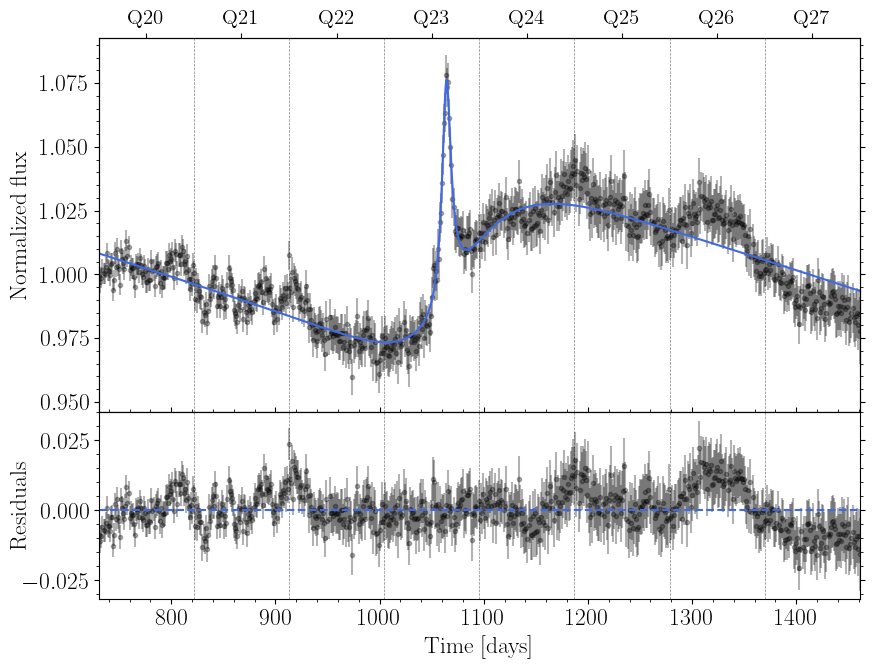

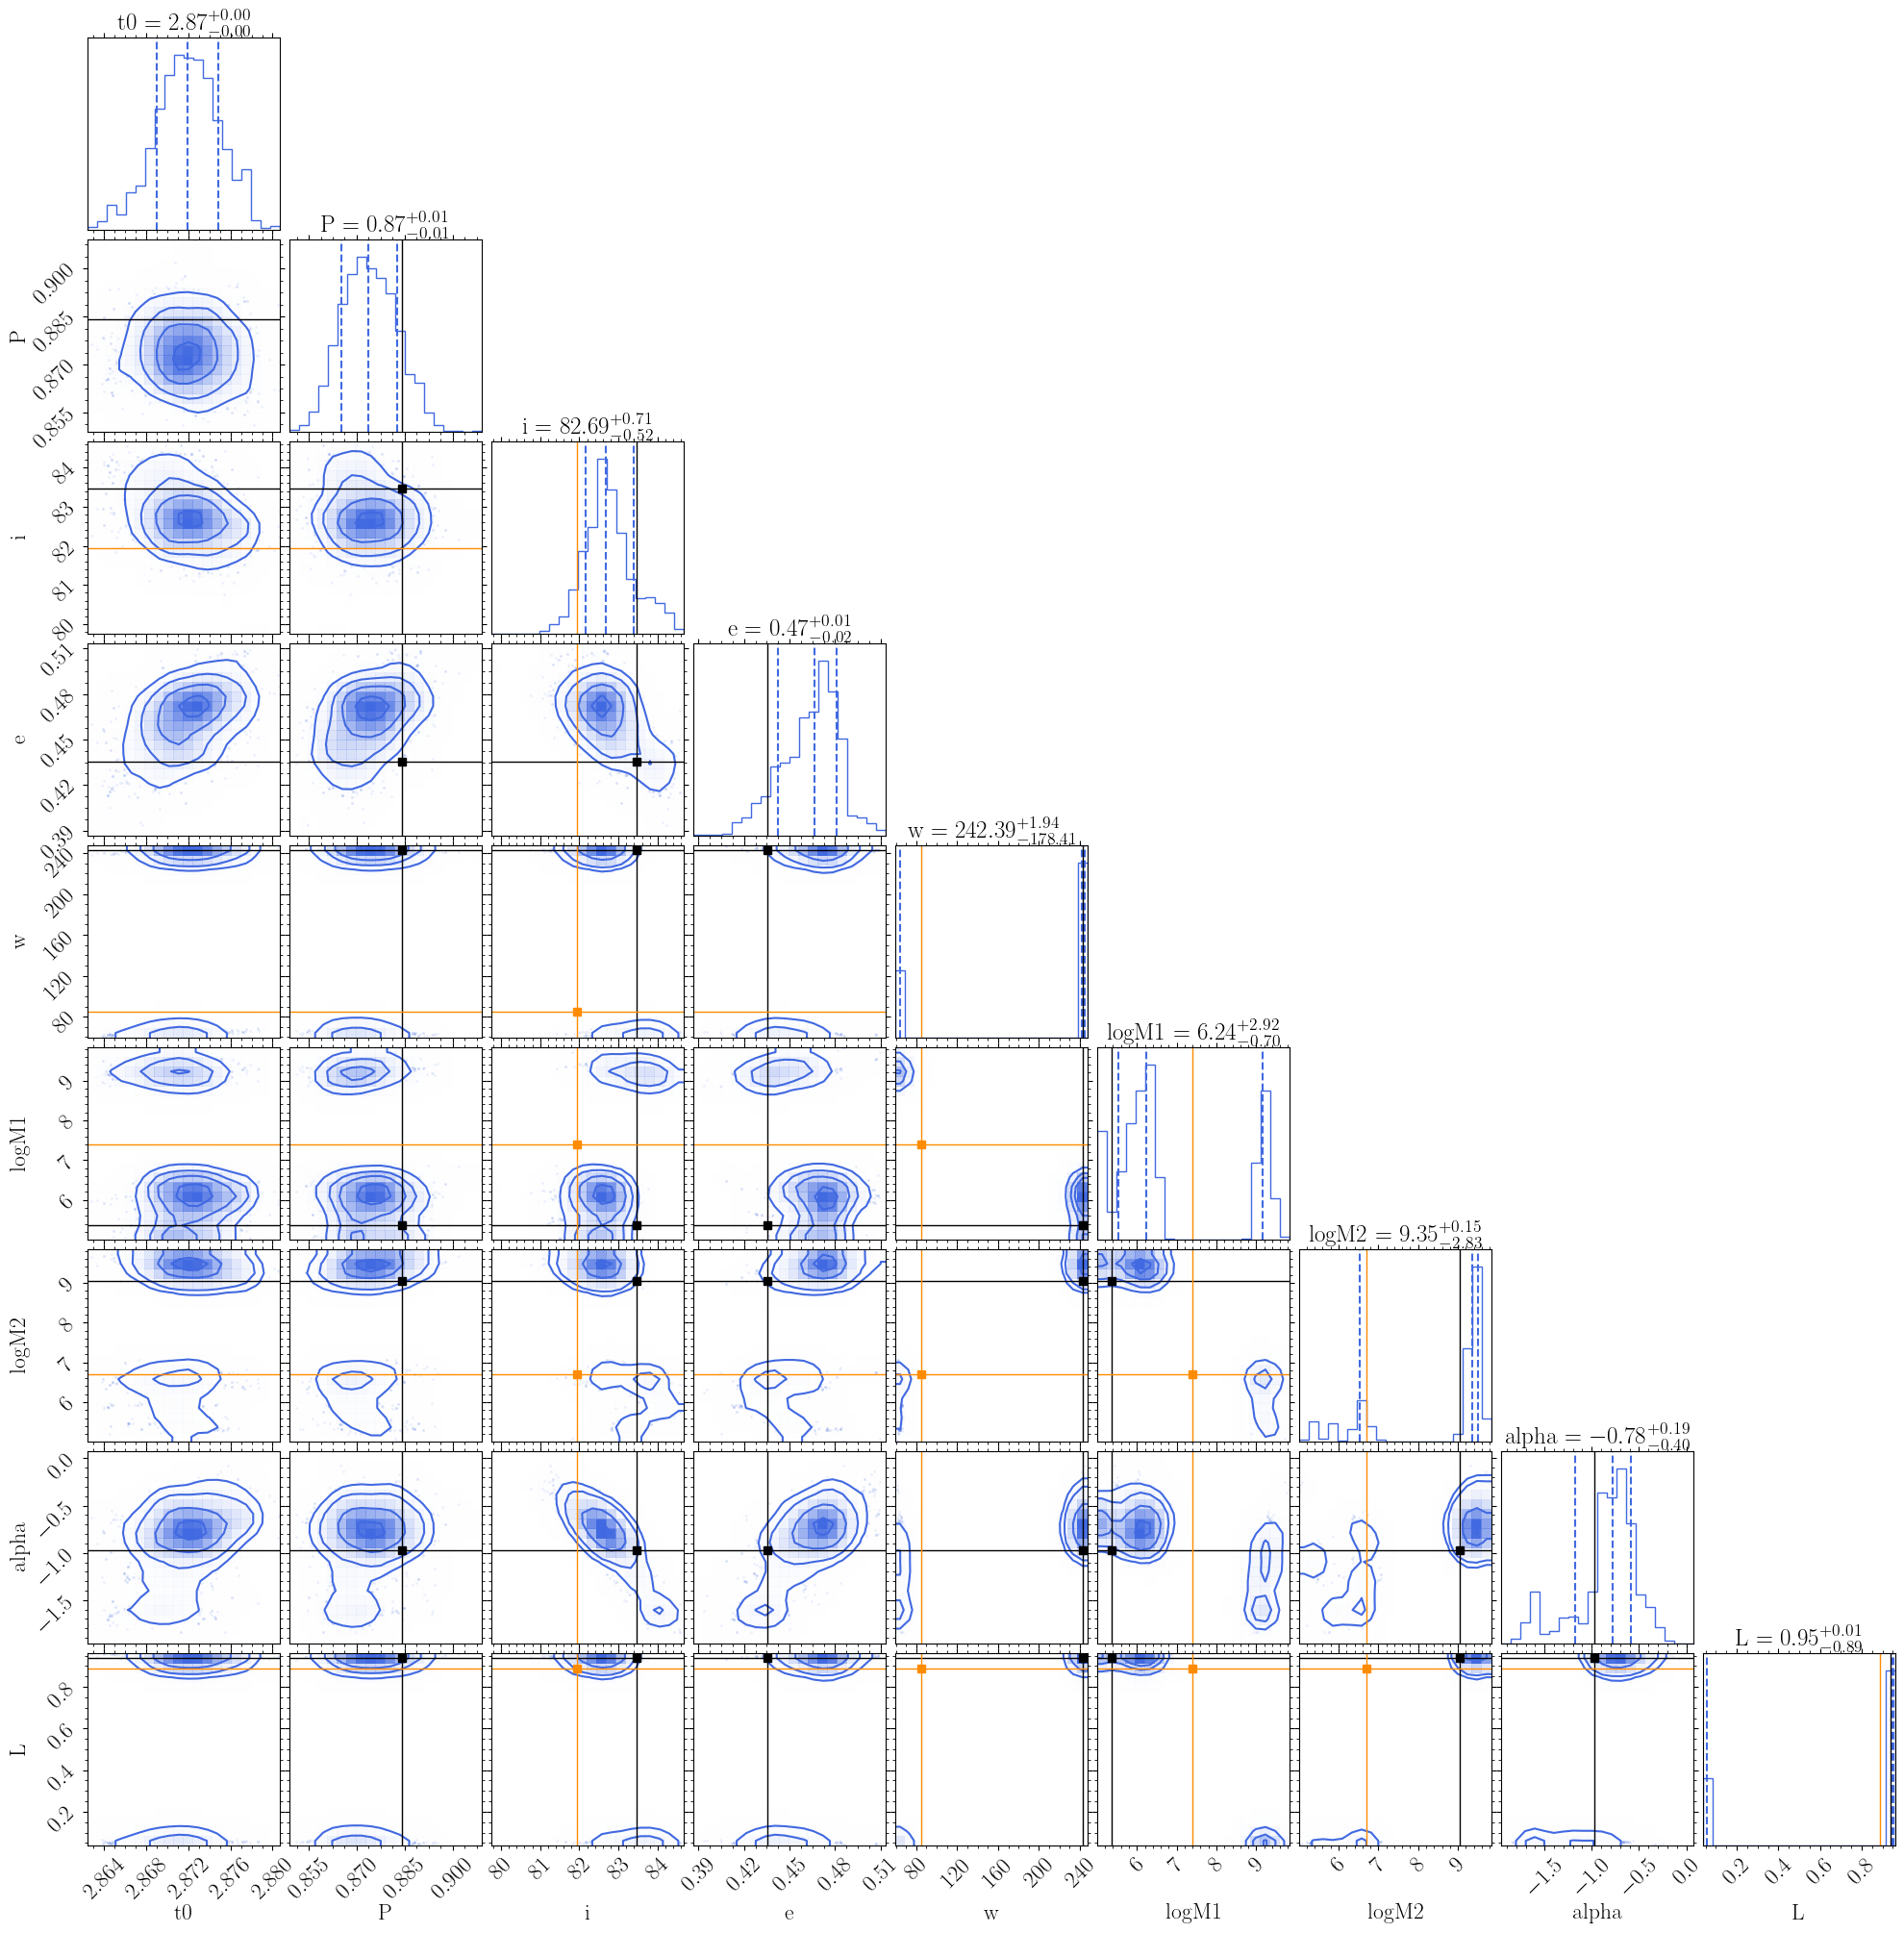

In [12]:
# Inspect cluster t00
result1 = clusters[0]
dm = smbhb.model_lightcurve(time, result1['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3);
fig = pt.plot_corner(result1, best_params='mle', true_params=True, color=c);

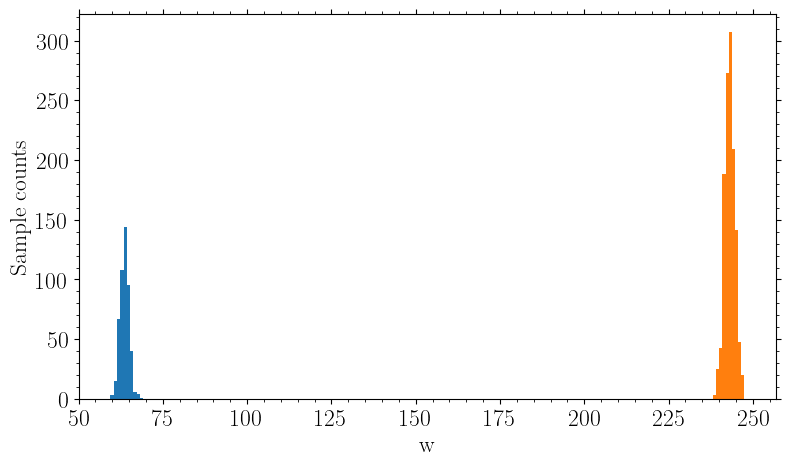

In [13]:
# Resolve bimodality in w
clusters = bs.get_posterior_clusters(df, result1, param_cluster='w', n_components=2)

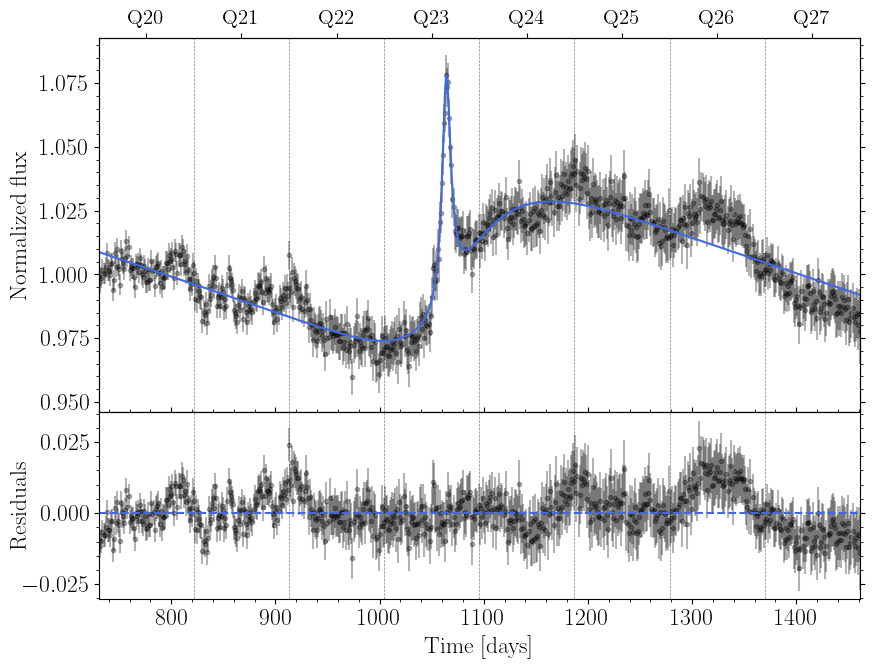

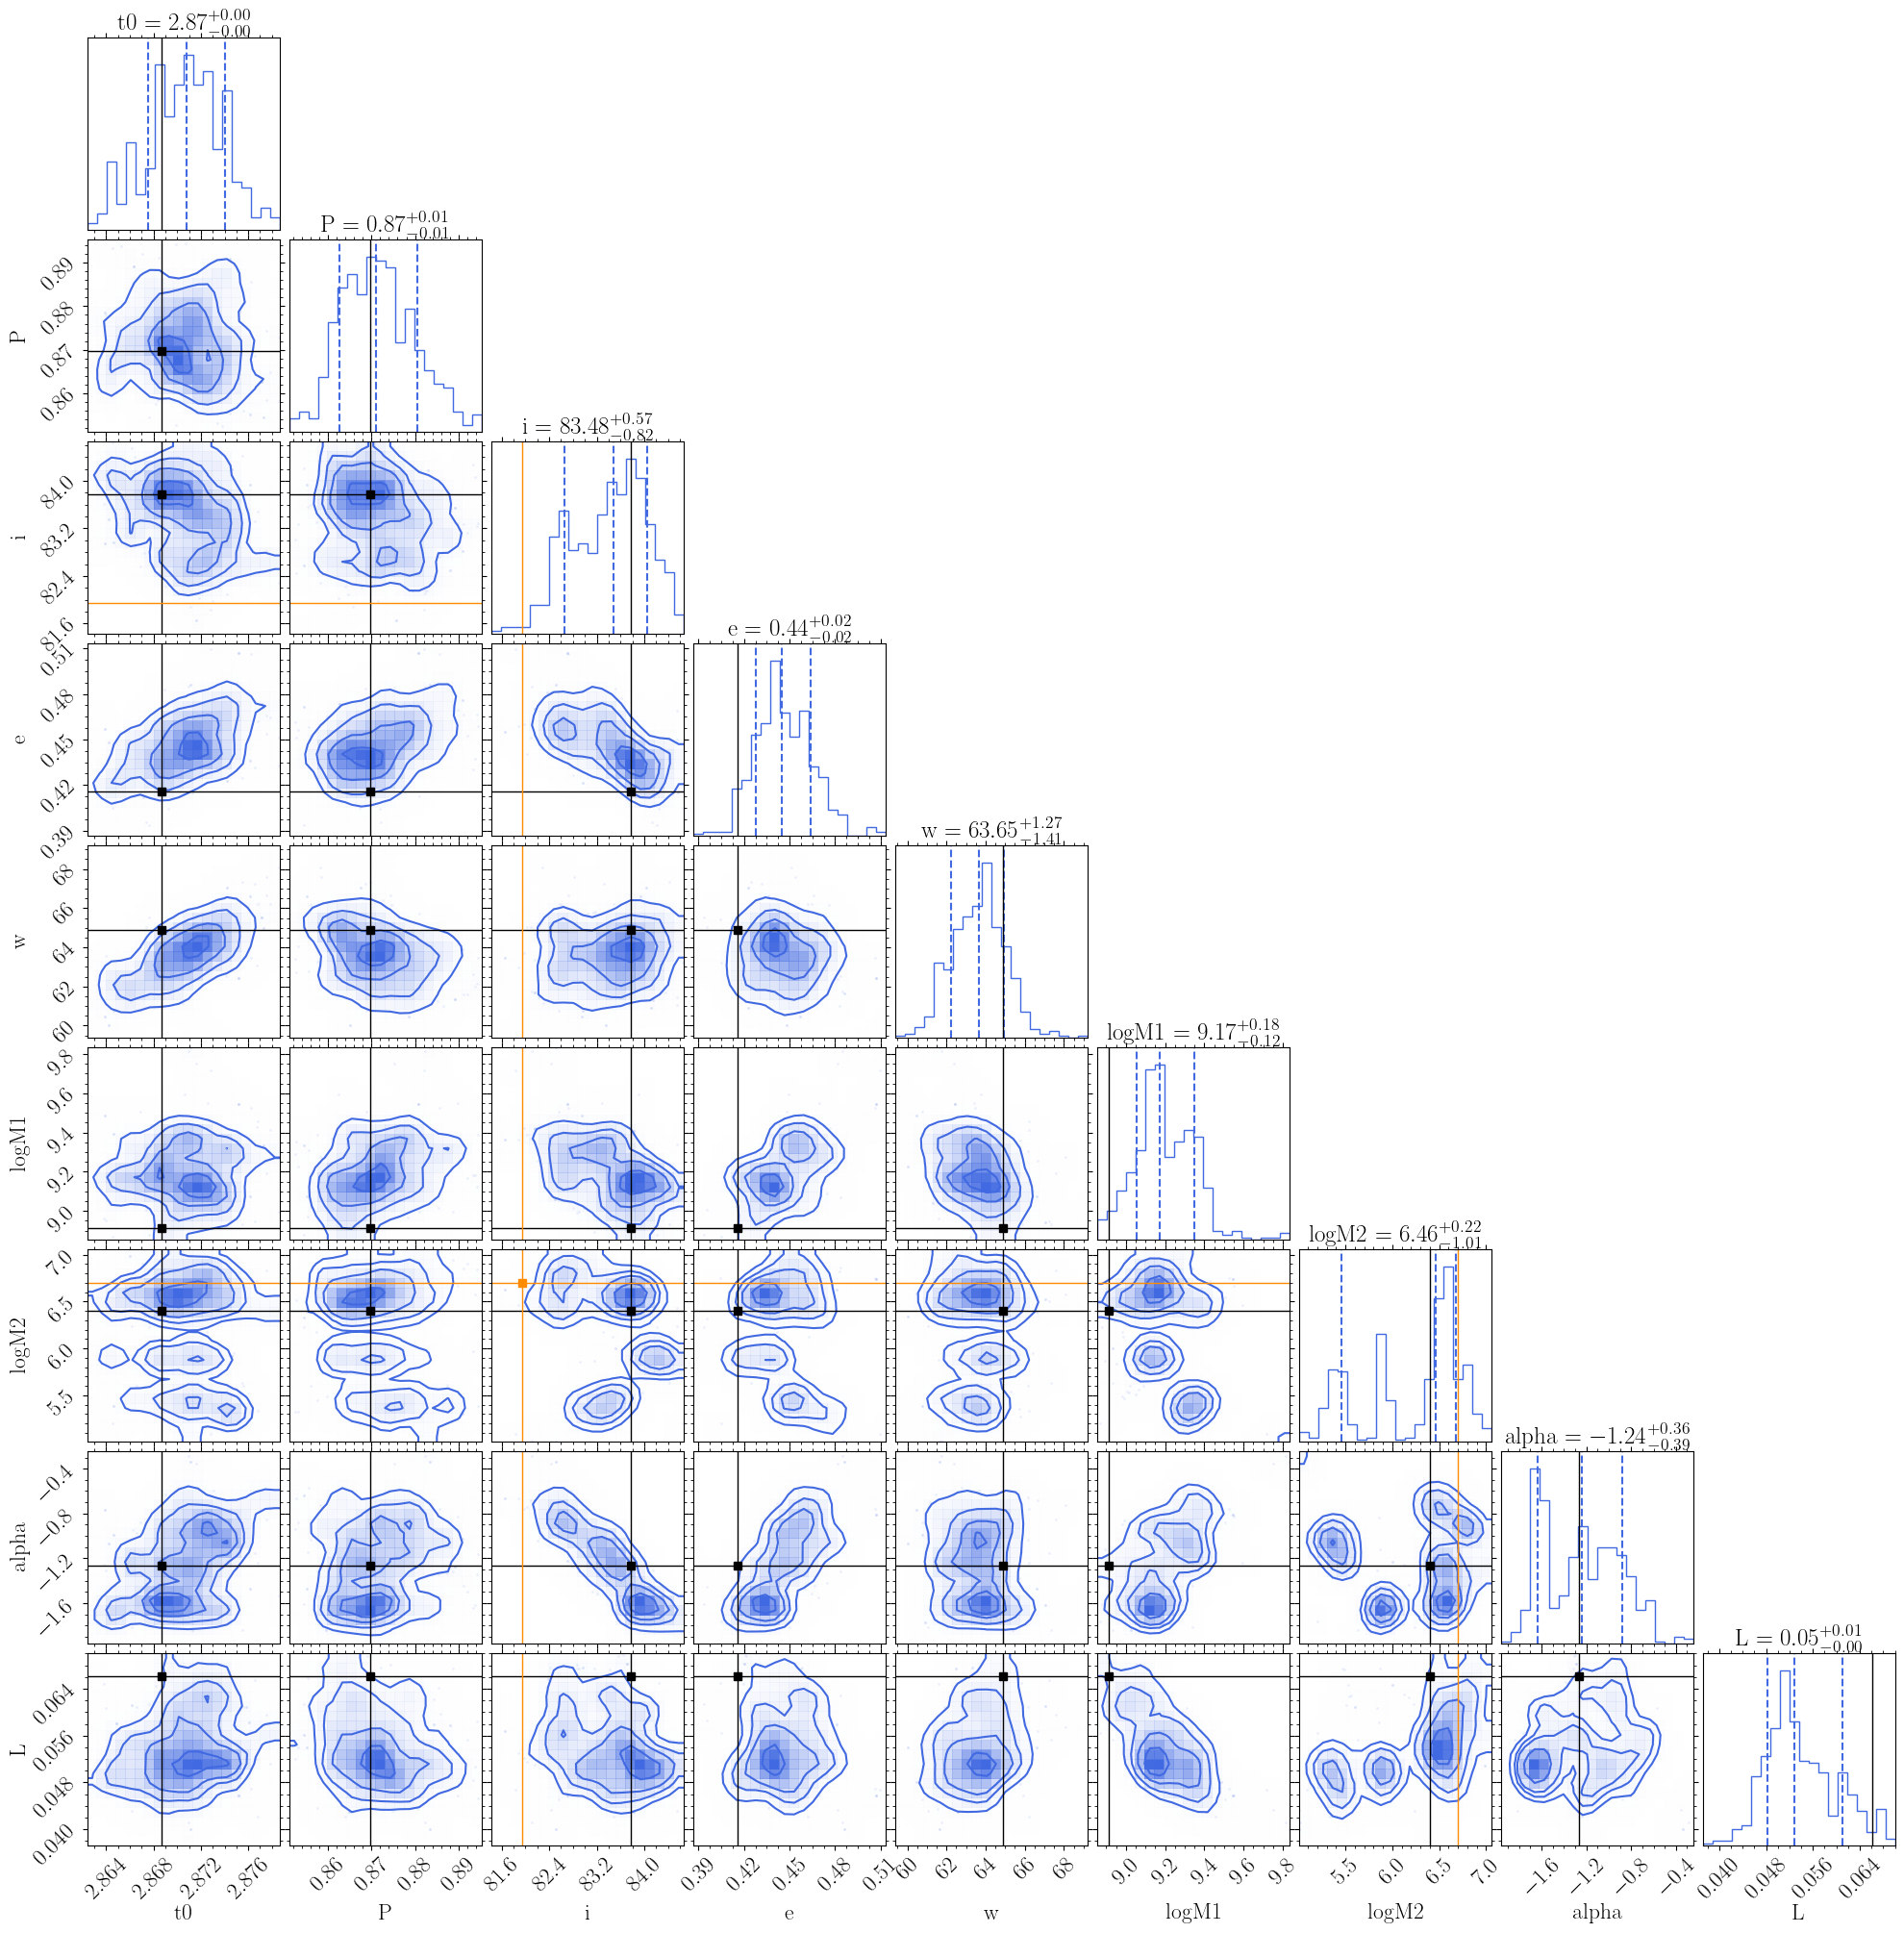

In [15]:
# Inspect cluster w0
result0 = clusters[0]
dm = smbhb.model_lightcurve(time, result0['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3);
fig = pt.plot_corner(result0, best_params='mle', true_params=True, color=c);

**Conclusion:** With only a 2-yr duration Plato light curve, the modelling is highly generate. The best-fit model here is seeing the system from the perspective +180 deg rotated which naturally swaps the meaning of M1 and M2.

---
## 2.2. Model DM (1-d cadence, 4-yr duration)
---

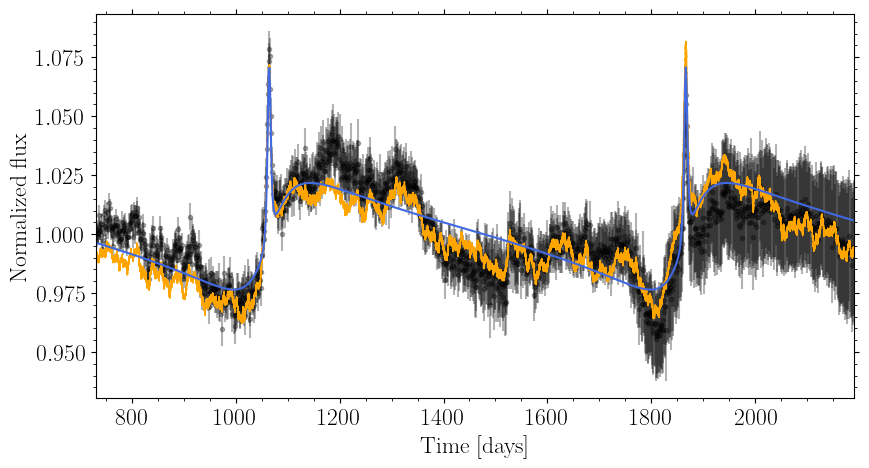

In [83]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_feather(ddir / 'lc_spikey_fiducial_1h.ftr')

# Bin to 1-hour light curve 
df = ut.bin_lc(df, bin_size=1)
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.t0    = 0.712
params.sigma = 0 
params.seed  = params.seed
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Load variable template
sdir = path / '../workdir/smbhb/simulations/lcs/'
dv = pd.read_csv(sdir / 'varsource' / 'varsource_spikey_fiducial.txt', 
                 sep=' ', names=['time', 'dmag'])
dv.time /= 86400
dv['flux'] = ut.mag2flux(dv.dmag)

# Plot light curve
fig, ax = pt.plot_lc(df, dv, cm='orange', lw=1, alpha=0.3)
ax.plot(dm.time, dm.flux, '-', c=c);

In [84]:
# We use wide uninformative uniform priors
folder = 'spikey_plato_bin1d4yr_DM_jaxns_uniform'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'vz'   : params.vz,
}

In [85]:
# %%time
# result = bs.run_jaxns(df, params, priors, bs.smbhb_mean_builder, ofile=rdir/folder/'result.npy')
result = ut.load_result(rdir/folder/'result.npy')

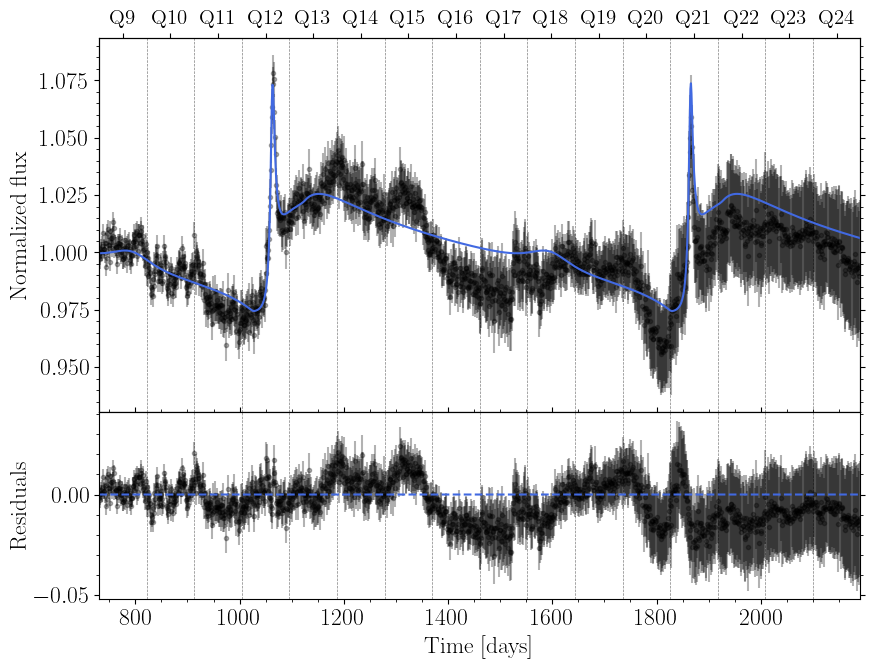

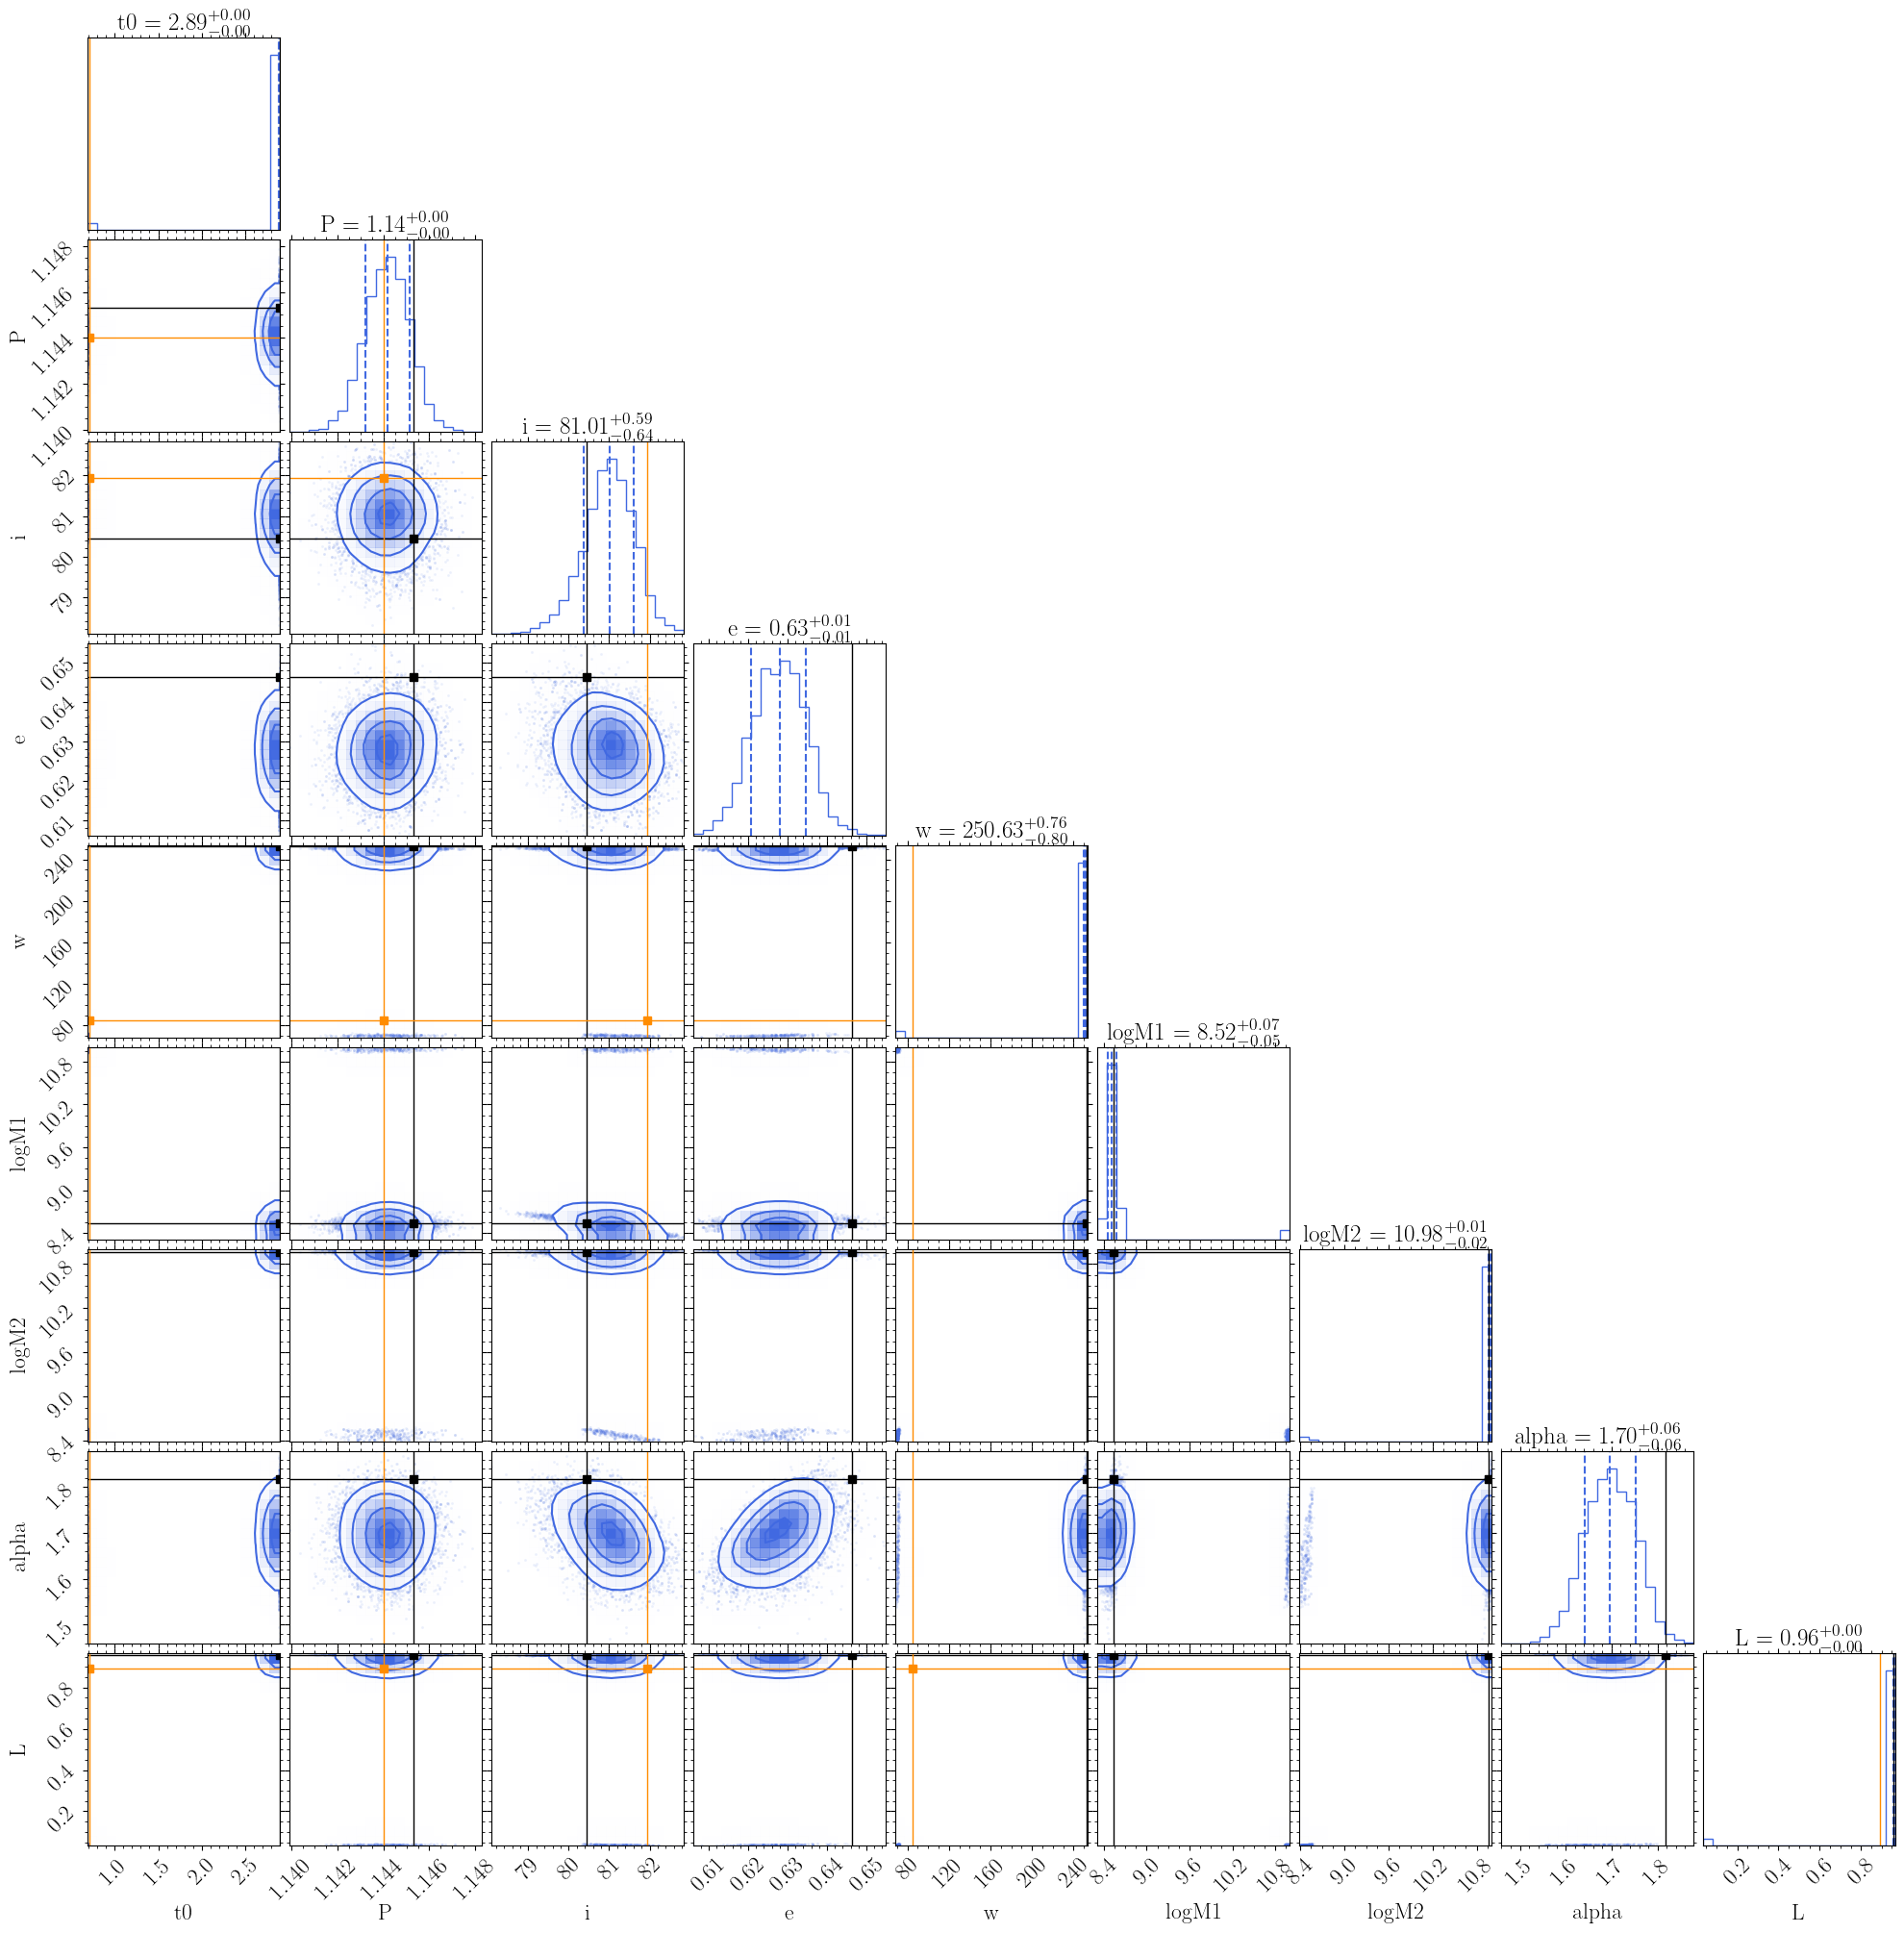

In [86]:
dm = smbhb.model_lightcurve(time, result['posterior']['map'])
fig, ax = pt.plot_result(df, dm, cm=c, Q0=1, alpha=0.3);
fig = pt.plot_corner(result, best_params='map', true_params=True, color=c);

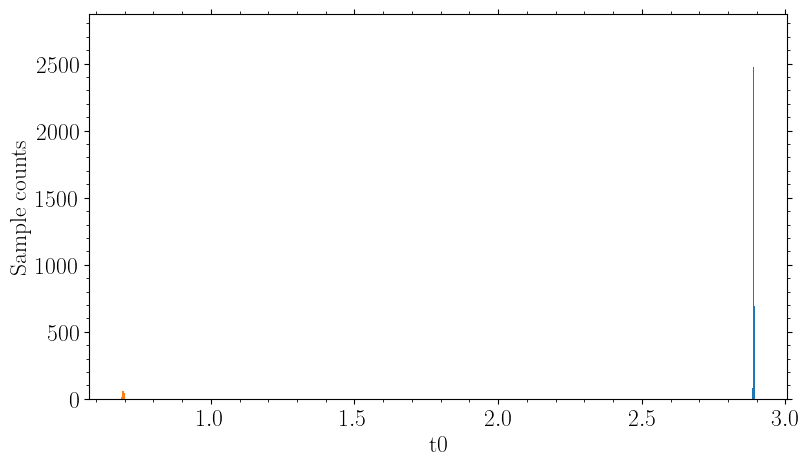

In [87]:
clusters = bs.get_posterior_clusters(df, result, param_cluster='t0', n_components=2)

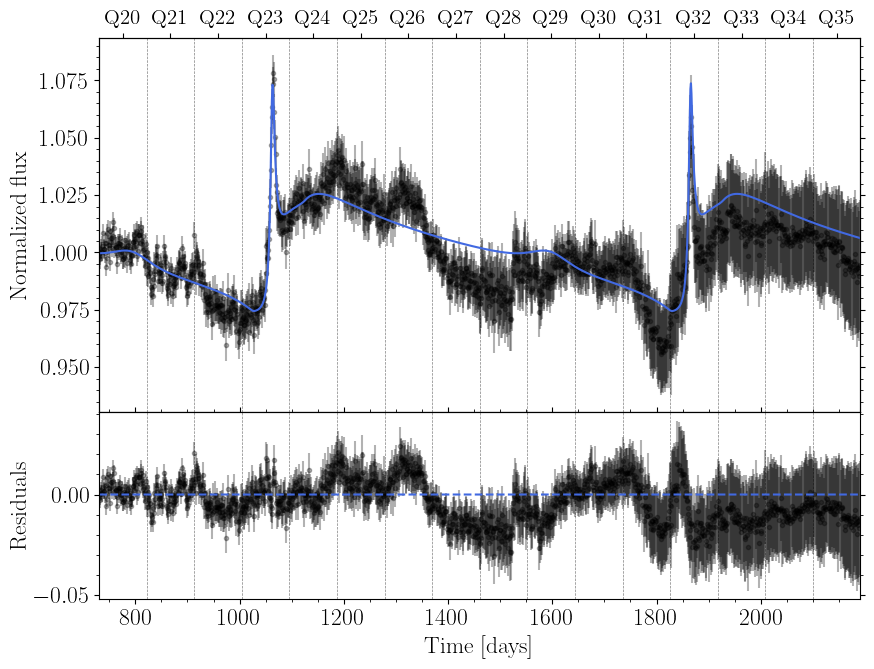

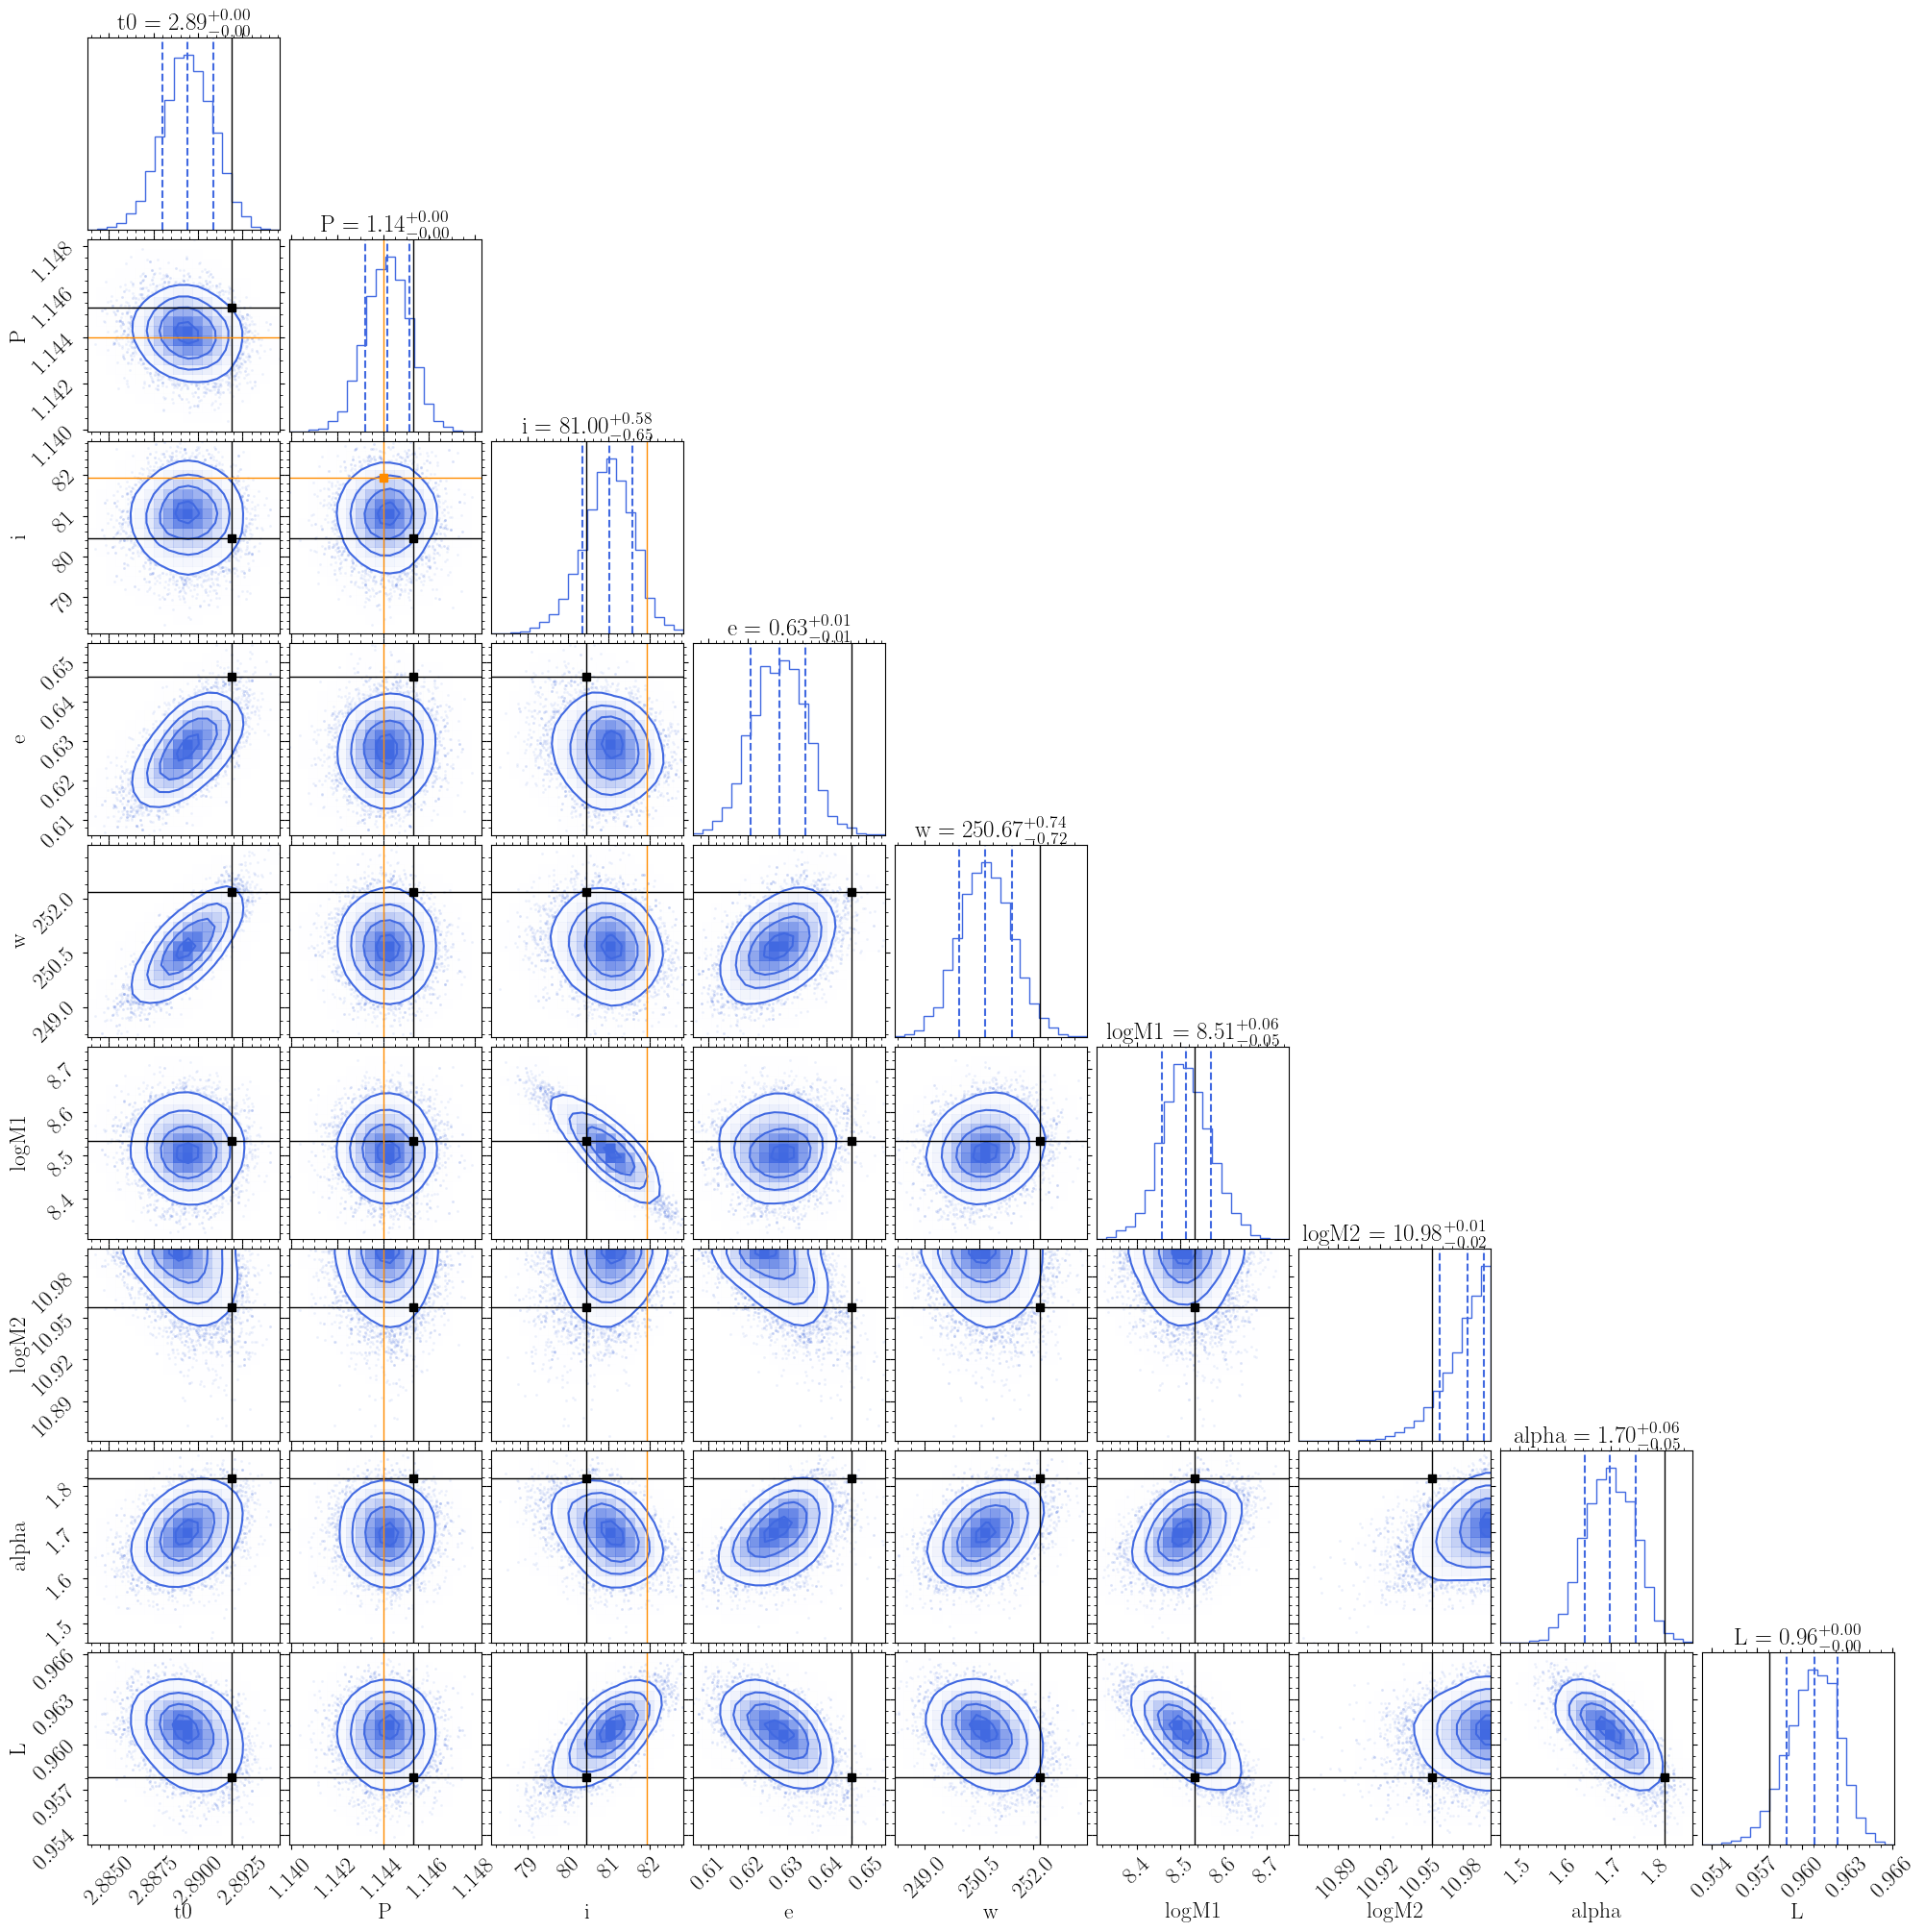

In [88]:
result0 = clusters[0]
dm = smbhb.model_lightcurve(time, result0['posterior']['map'])
fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3);
fig = pt.plot_corner(result0, best_params='map', true_params=True, color=c);

In [101]:
# result1 = clusters[1]
# dm = smbhb.model_lightcurve(time, result1['posterior']['map'])
# fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3);
# fig = pt.plot_corner(result1, best_params='map', true_params=True, color=c);

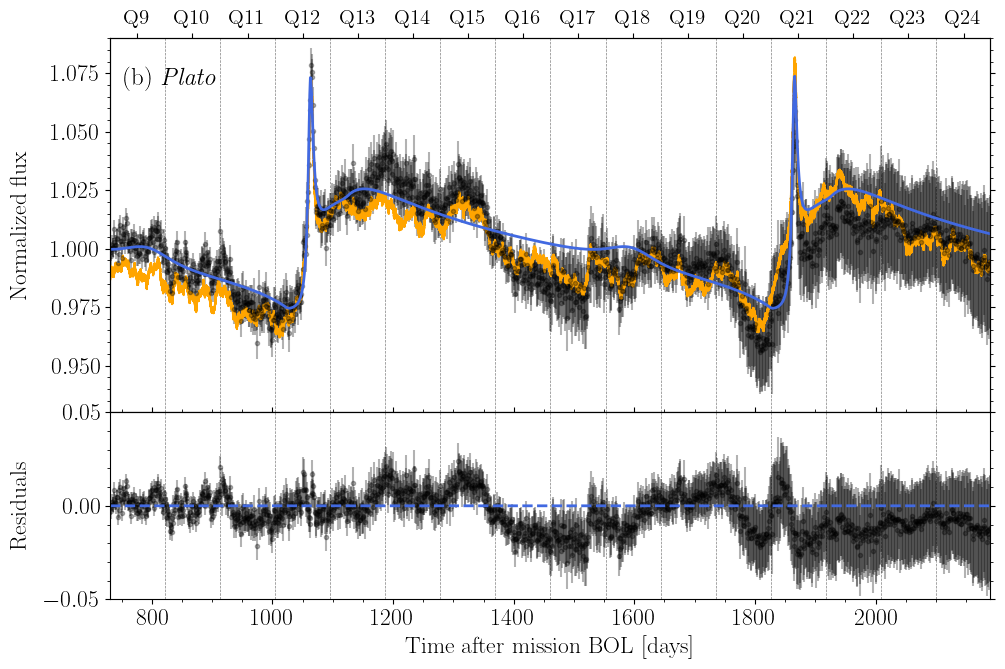

In [100]:
# Figure 6 (left) in paper
dm = smbhb.model_lightcurve(time, result0['posterior']['map'])
fig, ax = pt.plot_result(df, dm, cm=c, Q0=1, alpha=0.3, lw=2, figsize=(4/3.5*9,7))
ax[0].plot(dv.time, dv.flux, '-', c='orange', zorder=1);
ax[0].text(754, 1.07, r'(b) \textit{Plato}', fontsize=18)
ax[0].set_ylim(0.93, 1.09)
# ax[1].plot(dv.time, dm.flux.to_numpy()-dv.flux.to_numpy(), '-', c='orange', lw=1);
ax[1].set_ylim(-0.05, 0.05)
ax[1].set_xlabel('Time after mission BOL [days]')
fig.savefig(rdir/folder/'bestfit.png', bbox_inches='tight', dpi=200)

---
## 3.1. Model QDM (1-d cadence, 2-yr duration) 
---

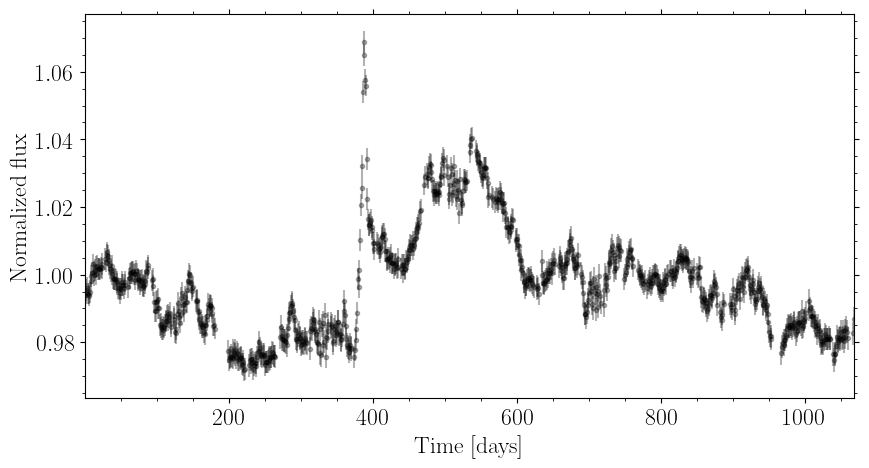

In [15]:
# Load Hu+2020 binned light curve of Spikey 
df_kepler = pd.read_csv(ddir / 'data_spikey_QDM_kepler_smith2016.csv')

# Create a 1-d binned light curve and plot
df_kepler = ut.bin_lc(df_kepler, bin_size=1)

# Plot light curve
pt.plot_lc(df_kepler, cm=c, alpha=0.3);